In [1]:
import re
import numpy as np
import pandas as pd
import h5py
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
from scipy.interpolate import griddata

In [20]:
folder='Site_2_Step1'
folder='../Forest_Model_Round1_write/Site_2_hourly/'
file_path = folder+'/ats_vis_surface_data.VisIt.xmf'

# Read the file content
with open(file_path, 'r') as file:
    content = file.read()

# Regular expression to match numbers between 'h5' and 'xmf'
pattern = r"h5\.(\d+)\.xmf"
matches = re.findall(pattern, content)

# Convert matches to integers
numbers = [int(match) for match in matches] # extract the timestep

In [12]:
loc=pd.read_csv('data/Site_1_surf_mesh_long.csv').iloc[:,[0,2]]
df=h5py.File(folder+'/ats_vis_surface_data.h5', 'r')
out=np.array([])
for i in range(len(numbers)):
    fin=loc.copy()
    fin['flux']=df['surface-surface_subsurface_flux'][str(numbers[i])]
    fin['depth']=df['surface-ponded_depth'][str(numbers[i])]
    fin.loc[fin['depth'] < 0.02, 'flux'] = np.nan
    #out=np.append(out,fin.loc[:5, 'flux'].mean())
    out=np.append(out,fin.loc[-10:, 'flux'].mean())
    #out=np.append(out,fin.loc[2, 'flux'])

In [21]:
loc=pd.read_csv('data/Site_2_surf_mesh_long.csv').iloc[:,[0,2]]
df=h5py.File(folder+'/ats_vis_surface_data.h5', 'r')
out=np.array([])
for i in range(len(numbers)):
    fin=loc.copy()
    fin['flux']=df['surface-surface_subsurface_flux'][str(numbers[i])]
    fin['depth']=df['surface-ponded_depth'][str(numbers[i])]
    #fin.loc[fin['depth'] < 0.02, 'flux'] = np.nan
    #out=np.append(out,fin.loc[:5, 'flux'].mean())
    out=np.append(out,fin.loc[:5, 'flux'].mean())
    #out=np.append(out,fin.loc[2, 'flux'])

In [18]:
year = 2024
month = 1
day = 1
number_of_days = 580
dates = pd.date_range(f'{year}-{month}-{day}', periods=int(number_of_days), freq="1d")


Text(0, 0.5, 'stream-groundwater flux (m/s)')

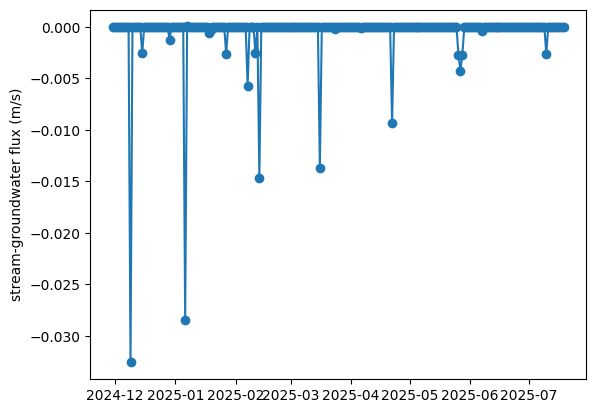

In [22]:
plt.plot(dates[334:334+232], out,'o-')
plt.ylabel("stream-groundwater flux (m/s)")

Text(0, 0.5, 'stream-groundwater flux (m/s)')

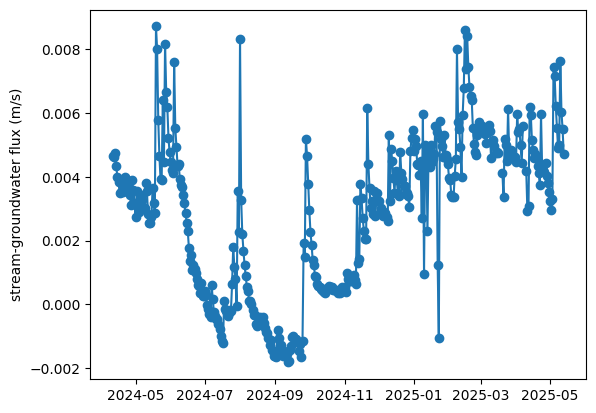

In [8]:
plt.plot(dates[101:101+398], out,'o-')
plt.ylabel("stream-groundwater flux (m/s)")

Text(0, 0.5, 'stream-groundwater flux (m/s)')

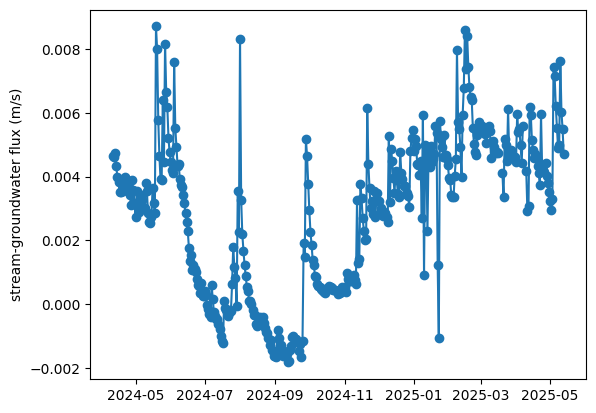

In [22]:

plt.plot(dates[101:101+398], out,'o-')
plt.ylabel("stream-groundwater flux (m/s)")
#plt.plot(pd.Series(out[83:244]).rolling(window=10, center=True, min_periods=1).mean())

Text(0, 0.5, 'stream-groundwater flux (m/s)')

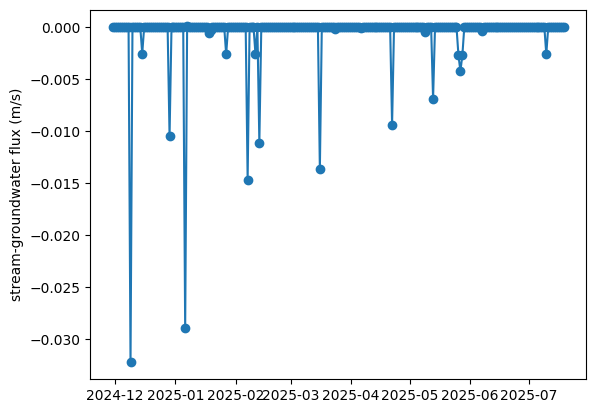

In [19]:
plt.plot(dates[334:334+232], out,'o-')
plt.ylabel("stream-groundwater flux (m/s)")